In [1]:
!pip install prophet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

In [3]:
df = pd.read_csv("cleaned_retail (1).xls")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47293 entries, 0 to 47292
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   InvoiceNo          47293 non-null  int64  
 1   StockCode          47293 non-null  object 
 2   Description        47293 non-null  object 
 3   Quantity           47293 non-null  int64  
 4   InvoiceDate        47293 non-null  object 
 5   UnitPrice          47293 non-null  float64
 6   CustomerID         44804 non-null  float64
 7   Country            47293 non-null  object 
 8   Discount           47293 non-null  float64
 9   PaymentMethod      47293 non-null  object 
 10  ShippingCost       47293 non-null  float64
 11  Category           47293 non-null  object 
 12  SalesChannel       47293 non-null  object 
 13  ReturnStatus       47293 non-null  object 
 14  ShipmentProvider   47293 non-null  object 
 15  WarehouseLocation  47293 non-null  object 
 16  OrderPriority      472

In [5]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Discount', 'PaymentMethod',
       'ShippingCost', 'Category', 'SalesChannel', 'ReturnStatus',
       'ShipmentProvider', 'WarehouseLocation', 'OrderPriority',
       'TotalRevenue', 'SaleDate', 'Month', 'Year'],
      dtype='object')


In [6]:
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

daily_sales = (
    df.groupby('SaleDate')['TotalRevenue']
      .sum()
      .reset_index()
)

daily_sales.head()

,SaleDate,TotalRevenue
0,2020-01-01,28231.6428
1,2020-01-02,22374.7898
2,2020-01-03,17314.3738
3,2020-01-04,19342.9045
4,2020-01-05,20390.1356


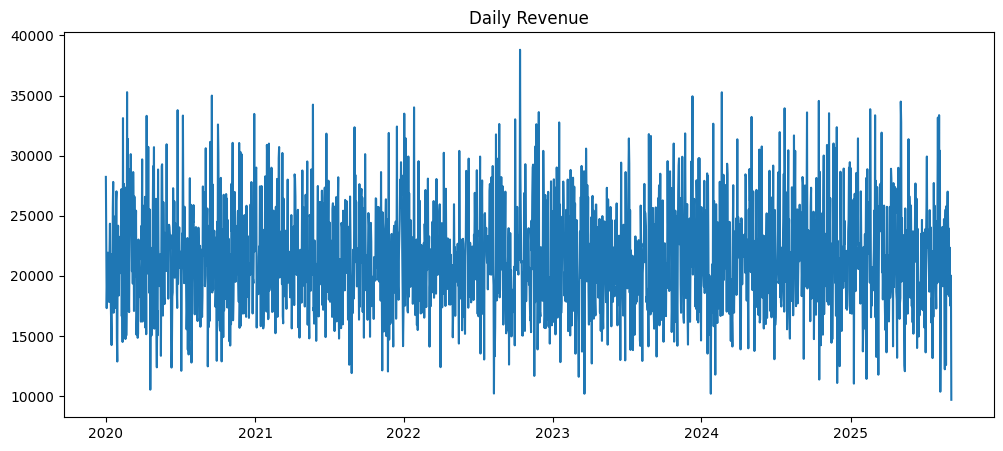

In [7]:
plt.figure(figsize=(12,5))
plt.plot(
    daily_sales['SaleDate'],
    daily_sales['TotalRevenue']
)

plt.title("Daily Revenue")
plt.show()

In [8]:
prophet_df = daily_sales.rename(
    columns={
        'SaleDate':'ds',
        'TotalRevenue':'y'
    }
)

In [9]:
prophet_df.head()

,ds,y
0,2020-01-01,28231.6428
1,2020-01-02,22374.7898
2,2020-01-03,17314.3738
3,2020-01-04,19342.9045
4,2020-01-05,20390.1356


In [10]:
model = Prophet()

model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [11]:
future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(future)

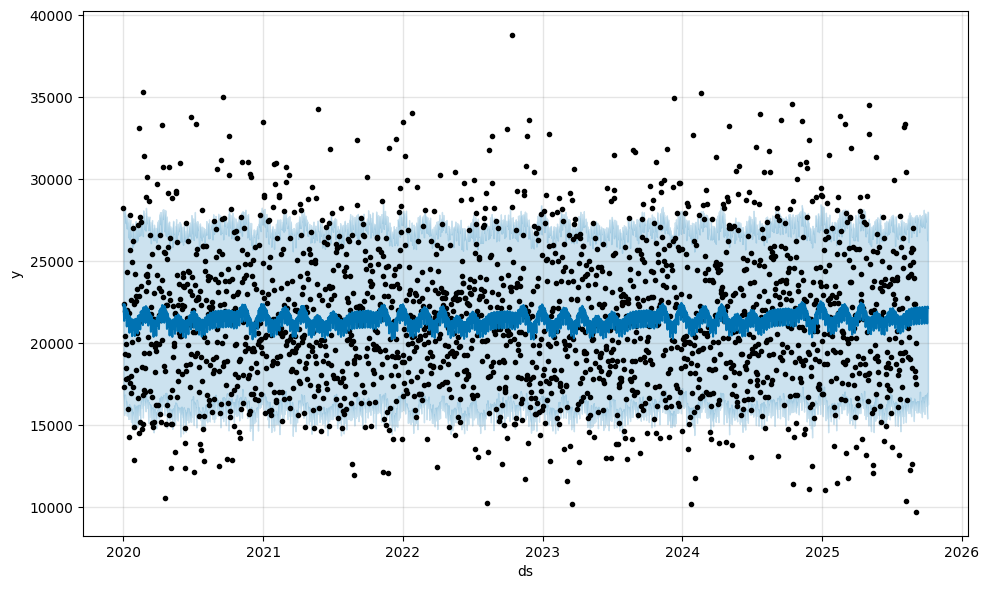

In [12]:
model.plot(forecast)
plt.show()

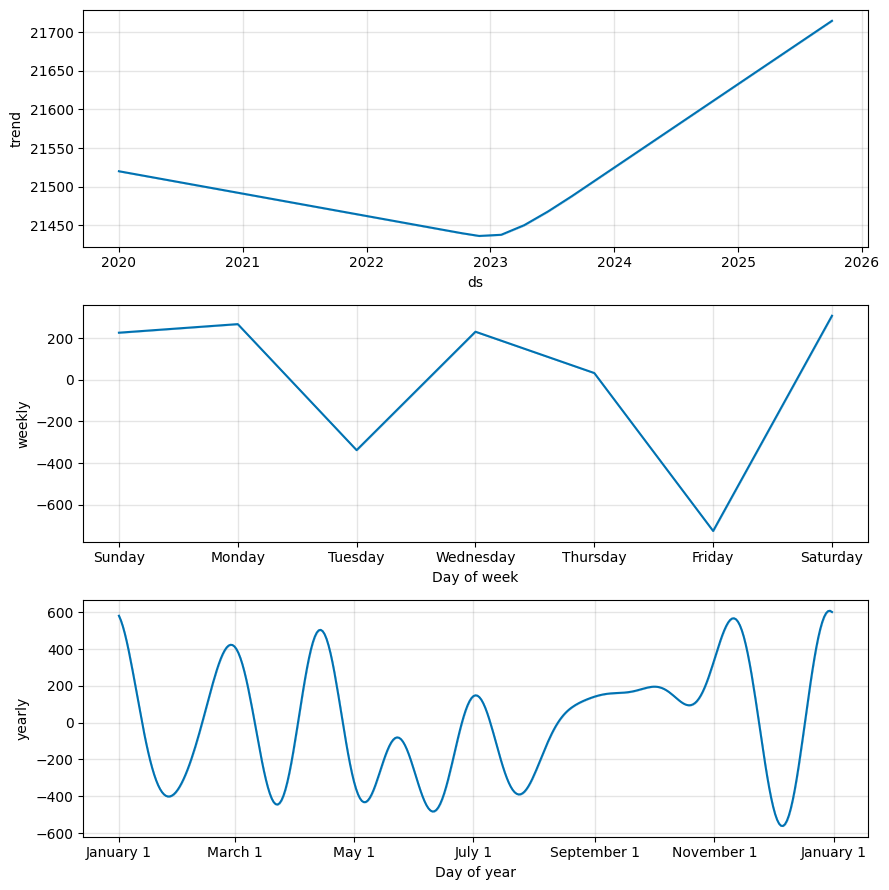

In [13]:
model.plot_components(forecast)
plt.show()

In [14]:
print(prophet_df.shape)

print(prophet_df['ds'].min())
print(prophet_df['ds'].max())

(2075, 2)
2020-01-01 00:00:00
2025-09-05 00:00:00


In [15]:
daily_sales.head()

,SaleDate,TotalRevenue
0,2020-01-01,28231.6428
1,2020-01-02,22374.7898
2,2020-01-03,17314.3738
3,2020-01-04,19342.9045
4,2020-01-05,20390.1356


In [16]:
daily_sales.describe()

,SaleDate,TotalRevenue
count,2075,2075.000000
mean,2022-11-03 00:00:00,21510.214201
min,2020-01-01 00:00:00,9691.172900
25%,2021-06-02 12:00:00,18405.854650
50%,2022-11-03 00:00:00,21295.628100
75%,2024-04-04 12:00:00,24194.124300
max,2025-09-05 00:00:00,38805.910500
std,NaN,4403.242987


In [17]:
train = prophet_df[:-30]
test = prophet_df[-30:]

In [18]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Create a future dataframe for the test set
future_test = test[['ds']]

# Generate predictions for the test set
forecast_test = model.predict(future_test)

mae = mean_absolute_error(test['y'], forecast_test['yhat'])

mape = np.mean(
    np.abs((test['y'] - forecast_test['yhat']) / test['y'])
) * 100

print("MAE:", mae)
print("MAPE:", mape)

MAE: 3944.0417862156555
MAPE: nan


In [19]:
forecast.to_csv(
    "prophet_forecast.csv",
    index=False
)

In [20]:
train = prophet_df[:-30]
test = prophet_df[-30:]

print(train.shape)
print(test.shape)

(2045, 2)
(30, 2)


In [21]:
from prophet import Prophet

model = Prophet()

model.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [22]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

In [23]:
forecast_test = forecast[['ds', 'yhat']].tail(30)

forecast_test.head()

,ds,yhat
2045,2025-08-07,21746.822686
2046,2025-08-08,21012.651025
2047,2025-08-09,22139.221523
2048,2025-08-10,22048.530451
2049,2025-08-11,22094.543745


In [24]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [25]:
mae = mean_absolute_error(
    test['y'],
    forecast_test['yhat']
)

rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        forecast_test['yhat']
    )
)

mape = np.mean(
    np.abs(
        (test['y'] - forecast_test['yhat'])
        / test['y']
    )
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 3957.6531404458433
RMSE: 5113.224156051215
MAPE: 24.64394373219822


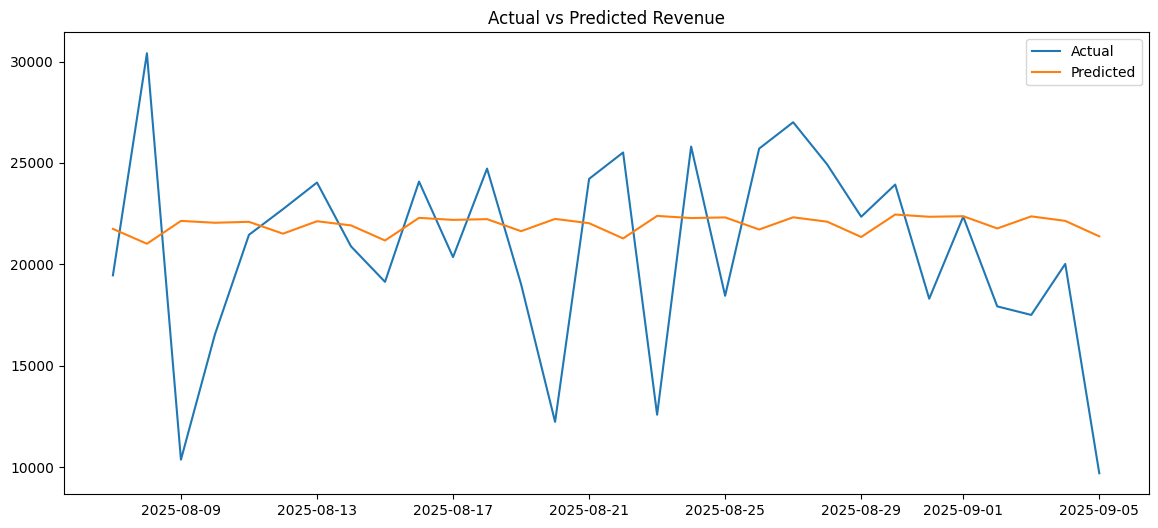

In [26]:
plt.figure(figsize=(14,6))

plt.plot(
    test['ds'],
    test['y'],
    label='Actual'
)

plt.plot(
    forecast_test['ds'],
    forecast_test['yhat'],
    label='Predicted'
)

plt.legend()
plt.title("Actual vs Predicted Revenue")
plt.show()

In [27]:
forecast.to_csv(
    "prophet_forecast.csv",
    index=False
)

In [28]:
forecast_test.to_csv(
    "prophet_test_predictions.csv",
    index=False
)